# Data Pipeline


In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
assets = [
"BTC-USD","ETH-USD","BNB-USD","SOL-USD","XRP-USD",
"ADA-USD","DOGE-USD","AVAX-USD","DOT-USD","LINK-USD",
"MATIC-USD","LTC-USD","ATOM-USD","NEAR-USD","UNI-USD",
"FIL-USD","ETC-USD","AAVE-USD","SAND-USD","MANA-USD",
"ALGO-USD","ICP-USD","EOS-USD","THETA-USD"
]

In [3]:
import requests

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

table = pd.read_html(response.text)

sp500 = table[0]

tickers = sp500["Symbol"].tolist()

print(len(tickers))

/tmp/ipykernel_1891/1041621776.py:11: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  table = pd.read_html(response.text)


503


In [4]:
data = yf.download(
    tickers,
    start="2019-01-01",
    end="2026-01-01"
)

/tmp/ipykernel_1891/3975864009.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  503 of 503 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['BF.B']: YFPricesMissingError('possibly delisted; no price data found  (1d 2019-01-01 -> 2026-01-01)')
ERROR:yfinance:['BRK.B']: YFTzMissingError('possibly delisted; no timezone found')


In [5]:
prices = data["Close"]
prices.head()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-02,62.442284,37.503738,65.326935,NaN,61.182671,24.904034,127.187752,224.570007,75.352348,33.040260,...,16.405535,97.230293,39.028111,50.001842,60.948055,57.200001,80.020233,93.876472,156.240005,79.459419
2019-01-03,60.141933,33.768093,63.174500,NaN,58.295185,24.514164,122.845352,215.699997,70.800690,32.895031,...,16.961786,96.289680,38.874332,49.234131,58.858719,52.419998,78.007523,92.178490,146.880005,76.712936
2019-01-04,62.223656,35.209606,65.209793,NaN,59.959011,25.094212,127.622055,226.190002,72.519638,33.653458,...,17.540895,100.173279,39.254738,51.049366,61.342087,58.180000,80.037766,95.326653,152.970001,79.722771
2019-01-07,63.544952,35.131237,66.161537,NaN,60.856945,25.037159,128.065323,229.259995,72.975700,33.822903,...,17.891409,101.952133,39.084759,51.314850,60.434864,60.720001,79.950256,95.363388,155.289993,80.202446
2019-01-08,64.476486,35.800961,66.469048,NaN,60.126278,25.132248,131.304062,232.679993,74.755997,34.452236,...,17.998087,105.146568,39.538017,51.687939,61.003021,63.119999,79.792747,93.224831,156.330002,81.396965


In [6]:
prices = prices.dropna(axis=1)
print("Price shape:", prices.shape)

Price shape: (1760, 476)


In [7]:
returns = prices.pct_change().dropna()
returns.head()

Ticker,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-03,-0.036840,-0.099607,-0.032949,-0.047194,-0.015655,-0.034142,-0.039498,-0.060405,-0.004396,-0.030198,...,0.033906,-0.009674,-0.003940,-0.015354,-0.034281,-0.083566,-0.025153,-0.018087,-0.059908,-0.034565
2019-01-04,0.034613,0.042689,0.032217,0.028541,0.023662,0.038884,0.048632,0.024279,0.023056,0.039854,...,0.034142,0.040332,0.009786,0.036869,0.042192,0.109882,0.026026,0.034153,0.041462,0.039235
2019-01-07,0.021235,-0.002226,0.014595,0.014976,-0.002274,0.003473,0.013573,0.006289,0.005035,-0.005410,...,0.019983,0.017758,-0.004330,0.005201,-0.014790,0.043658,-0.001093,0.000385,0.015166,0.006017
2019-01-08,0.014659,0.019063,0.004648,-0.012006,0.003798,0.025290,0.014918,0.024396,0.018607,0.005899,...,0.005963,0.031333,0.011597,0.007271,0.009401,0.039526,-0.001970,-0.022425,0.006697,0.014894
2019-01-09,0.020934,0.016981,-0.032823,0.016691,0.012864,0.005029,0.011819,0.025340,0.008665,0.000914,...,0.003387,0.013020,-0.007984,0.005275,0.016223,0.044518,-0.000438,0.008172,0.024819,-0.003582


# Momentum


In [8]:
momentum = prices.pct_change(90)
momentum.tail()

Ticker,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-24,0.173066,0.187039,0.120914,-0.037653,0.066962,0.083691,-0.011925,0.207696,-0.015137,-0.137229,...,-0.058334,0.158386,0.034071,0.126900,-0.009526,-0.139189,0.043280,-0.118069,-0.225463,-0.173274
2025-12-26,0.154507,0.186958,0.123420,-0.044609,0.043881,0.059442,-0.020026,0.210365,-0.017695,-0.143444,...,-0.082354,0.104476,0.024349,0.118524,-0.015874,-0.108075,0.017782,-0.127675,-0.210825,-0.186295
2025-12-29,0.160330,0.212448,0.111662,-0.055241,0.038238,0.063870,-0.000764,0.134061,-0.033252,-0.150098,...,-0.068683,0.098769,0.028797,0.120282,-0.018916,-0.111351,0.029421,-0.141504,-0.193608,-0.193553
2025-12-30,0.177092,0.215406,0.104517,-0.042884,0.033355,0.063034,-0.002603,0.121204,-0.040245,-0.138964,...,-0.052539,0.087381,0.029909,0.117351,-0.013252,-0.115400,0.038058,-0.126085,-0.200220,-0.184820
2025-12-31,0.120967,0.194782,0.092769,-0.050855,0.026871,0.035028,-0.033417,0.083403,-0.078600,-0.154936,...,-0.101352,0.054848,0.010140,0.090875,-0.047280,-0.177326,0.032895,-0.160898,-0.247746,-0.193857


In [9]:
momentum.iloc[-1].sort_values(ascending=False)
top_assets = momentum.iloc[-1].nlargest(3).index
top_assets

Index(['CIEN', 'MU', 'WBD'], dtype='object', name='Ticker')

In [10]:
weights = np.repeat(1/len(top_assets), len(top_assets))
weights

array([0.33333333, 0.33333333, 0.33333333])

# Backtesting


In [20]:
portfolio_returns = []
dates = returns.index[30:]

In [21]:
for date in dates:
    prev_date = prices.index[prices.index.get_loc(date) - 1]
    past_prices = prices.loc[:prev_date]
    mom = past_prices.pct_change(126).iloc[-1]
    top_assets = mom.nlargest(25).index
    daily_return = returns.loc[date, top_assets].mean()
    portfolio_returns.append(daily_return)

In [22]:
portfolio_returns = pd.Series(portfolio_returns, index=dates)

In [23]:
equity_curve = (1 + portfolio_returns).cumprod()

equity_curve = equity_curve / equity_curve.iloc[0]

In [24]:
buy_hold_prices = prices / prices.iloc[0]

buy_hold_curve = buy_hold_prices.mean(axis=1)

buy_hold_curve = buy_hold_curve.loc[equity_curve.index]

buy_hold_curve = buy_hold_curve / buy_hold_curve.iloc[0]

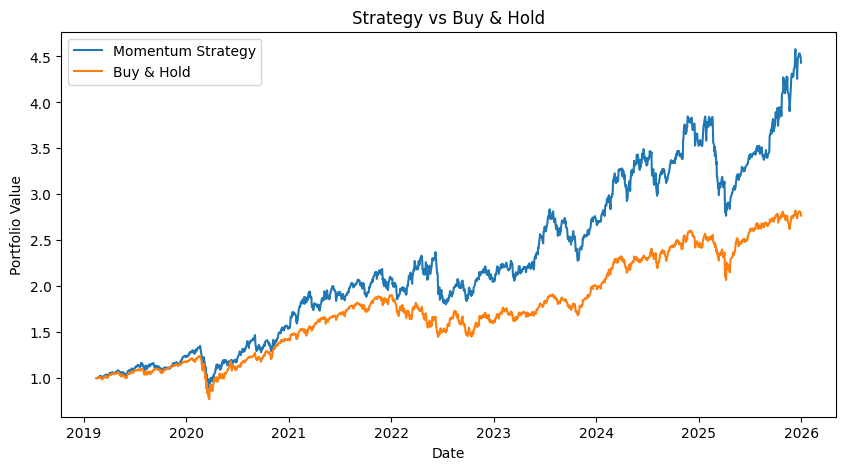

In [25]:
plt.figure(figsize=(10,5))

plt.plot(equity_curve, label="Momentum Strategy")
plt.plot(buy_hold_curve, label="Buy & Hold")

plt.legend()
plt.title("Strategy vs Buy & Hold")

plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.show()

In [26]:
print(buy_hold_curve.iloc[-1])

2.768145158135337


In [27]:
sharpe = portfolio_returns.mean() / portfolio_returns.std() * np.sqrt(252)

print("Sharpe Ratio:", sharpe)

Sharpe Ratio: 1.007653975597476


In [28]:
rolling_max = equity_curve.cummax()
drawdown = (equity_curve - rolling_max) / rolling_max

max_dd = drawdown.min()

print("Max Drawdown:", max_dd)

Max Drawdown: -0.3354647425831515


In [34]:
def run_strategy(prices, returns, window, basket):

    momentum = prices.shift(21).pct_change(window)

    dates = returns.index[window+1:]

    portfolio_returns = []

    for date in dates:

        prev_date = prices.index[prices.index.get_loc(date)-1]

        mom = momentum.loc[prev_date]

        top_assets = mom.nlargest(basket).index

        daily_return = returns.loc[date, top_assets].mean()

        portfolio_returns.append(daily_return)

    portfolio_returns = pd.Series(portfolio_returns)

    sharpe = portfolio_returns.mean() / portfolio_returns.std() * np.sqrt(252)

    return sharpe

In [35]:
train_prices = prices.loc[:'2021-12-31']
test_prices = prices.loc['2022-01-01':]

train_returns = returns.loc[:'2021-12-31']
test_returns = returns.loc['2022-01-01':]

In [ ]:
!pip install optuna

In [36]:
import optuna

def objective(trial):

    window = trial.suggest_int("window", 63, 252)
    basket = trial.suggest_int("basket", 5, 40)

    sharpe = run_strategy(train_prices, train_returns, window, basket)

    return sharpe

study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=40)

print(study.best_params)

[I 2026-03-10 08:14:32,505] A new study created in memory with name: no-name-b3c8fd8a-5113-443a-ba95-a9d0415bde75
[I 2026-03-10 08:14:34,107] Trial 0 finished with value: 1.2250516551649715 and parameters: {'window': 216, 'basket': 12}. Best is trial 0 with value: 1.2250516551649715.
[I 2026-03-10 08:14:35,642] Trial 1 finished with value: 1.0807517027207245 and parameters: {'window': 108, 'basket': 30}. Best is trial 0 with value: 1.2250516551649715.
[I 2026-03-10 08:14:36,831] Trial 2 finished with value: 1.570040577003379 and parameters: {'window': 149, 'basket': 7}. Best is trial 2 with value: 1.570040577003379.
[I 2026-03-10 08:14:37,946] Trial 3 finished with value: 1.06247353673839 and parameters: {'window': 181, 'basket': 25}. Best is trial 2 with value: 1.570040577003379.
[I 2026-03-10 08:14:39,245] Trial 4 finished with value: 1.2277996762307803 and parameters: {'window': 104, 'basket': 35}. Best is trial 2 with value: 1.570040577003379.
[I 2026-03-10 08:14:40,433] Trial 5 fi

{'window': 140, 'basket': 7}


In [39]:
run_strategy(test_prices, test_returns, 140, 7)

np.float64(1.3135485876072637)

In [41]:
spy = yf.download("SPY", start="2015-01-01", end="2026-01-01")["Close"]
spy_returns = spy.pct_change().dropna()
spy_sharpe = spy_returns.mean()/spy_returns.std()*np.sqrt(252)

spy_sharpe

/tmp/ipykernel_1891/2679798649.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy = yf.download("SPY", start="2015-01-01", end="2026-01-01")["Close"]
[*********************100%***********************]  1 of 1 completed


,0
Ticker,
SPY,0.799137
